# TROPOMI ↔ OCI L1B co-location

Step 1: **time + bounding-box** granule pairing.

**CLI:** `python TROPOMI_OCI_colocation/co_locate_cleanup.py --year 2025 --month 7 --day-end 31 -o TROPOMI_OCI_colocation/notebooks/co-location_results_202507.json`

**Speed knobs (current):**
1. Only the first `DAY_END` days of July (`DAY_END=7`)
2. Trust **filename times** (no NetCDF open for timing)
3. No `NUM` cap — use every `PACE_STRIDE`-th PACE granule in that window

NetCDF is opened only for **bbox** (PACE geo + TROPOMI chunk geo on time hits).

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path

import netCDF4 as nc
import numpy as np

# ── config (adjustable) ──────────────────────────────────────────────────────
YEAR, MONTH = 2025, 7
DAY_START = 1          # inclusive
DAY_END = 31            # inclusive — first 7 days of July

PACE_DIR = Path("/home/zhe2/data/PACE/L1B_V3")
# July 2025 BD5 is on kiwi; squid L1/2025 currently ends ~Feb 2025.
TROPOMI_DIR = Path(
    "/kiwi-data/Data/groupMembers/zhe2/MyProjects/TROPOMI_SIF/ESA/L1/2025"
)
TROPOMI_PRODUCT = "OFFL"  # "OFFL" | "RPRO" | "BOTH"

PACE_STRIDE = 1       # every N-th PACE granule
PACE_DURATION_MIN = 5  # filename has start only; approximate end ≈ start + this
DT_MAX_MIN = 60.0      # max |Δt| between granule mid-times (minutes)
BBOX_MARGIN_DEG = 0.5
TROPO_SCAN_STRIDE = 40   # coarser → faster TROPOMI geo reads
TROPO_PIX_STRIDE = 20
TROPO_CHUNK_SCANS = 400

In [2]:
@dataclass(frozen=True)
class TimeWindow:
    path: Path
    start: datetime
    end: datetime
    orbit: int | None = None

    @property
    def mid(self) -> datetime:
        return self.start + (self.end - self.start) / 2


@dataclass(frozen=True)
class BBox:
    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float  # if lon_min > lon_max, box crosses antimeridian


def expand_bbox(b: BBox, margin: float) -> BBox:
    return BBox(
        lat_min=max(-90.0, b.lat_min - margin),
        lat_max=min(90.0, b.lat_max + margin),
        lon_min=((b.lon_min - margin + 180) % 360) - 180,
        lon_max=((b.lon_max + margin + 180) % 360) - 180,
    )


def lon_intervals_overlap(a0: float, a1: float, b0: float, b1: float) -> bool:
    def parts(lo: float, hi: float) -> list[tuple[float, float]]:
        if lo <= hi:
            return [(lo, hi)]
        return [(lo, 180.0), (-180.0, hi)]

    for x0, x1 in parts(a0, a1):
        for y0, y1 in parts(b0, b1):
            if x0 <= y1 and y0 <= x1:
                return True
    return False


def bboxes_overlap(a: BBox, b: BBox) -> bool:
    if a.lat_max < b.lat_min or b.lat_max < a.lat_min:
        return False
    return lon_intervals_overlap(a.lon_min, a.lon_max, b.lon_min, b.lon_max)


def bbox_from_latlon(lat: np.ndarray, lon: np.ndarray) -> BBox | None:
    m = np.isfinite(lat) & np.isfinite(lon)
    if not m.any():
        return None
    lat_v, lon_v = lat[m], lon[m]
    lon_rad = np.deg2rad(lon_v)
    mean = np.angle(np.mean(np.exp(1j * lon_rad)))
    centered = (lon_rad - mean + np.pi) % (2 * np.pi) - np.pi
    lo = ((np.rad2deg(mean + centered.min()) + 180) % 360) - 180
    hi = ((np.rad2deg(mean + centered.max()) + 180) % 360) - 180
    return BBox(float(lat_v.min()), float(lat_v.max()), float(lo), float(hi))


def time_close(a: TimeWindow, b: TimeWindow, dt_max_min: float) -> bool:
    if a.start <= b.end and b.start <= a.end:
        return True
    return abs((a.mid - b.mid).total_seconds()) / 60.0 <= dt_max_min

In [3]:
# ── discover granules (filename times only) ───────────────────────────────────
PACE_NAME_RE = re.compile(r"PACE_OCI\.(\d{8}T\d{6})\.L1B\.V3\.nc$")
TROPO_NAME_RE = re.compile(
    r"S5P_(OFFL|RPRO)_L1B_RA_BD5_(\d{8}T\d{6})_(\d{8}T\d{6})_(\d+)_.+\.nc$"
)

window_start = datetime(YEAR, MONTH, DAY_START, tzinfo=timezone.utc)
window_end = datetime(YEAR, MONTH, DAY_END, 23, 59, 59, tzinfo=timezone.utc)


def overlaps_window(start: datetime, end: datetime) -> bool:
    return start <= window_end and end >= window_start


def list_pace() -> list[TimeWindow]:
    out: list[TimeWindow] = []
    for p in sorted(PACE_DIR.glob(f"PACE_OCI.{YEAR}{MONTH:02d}*.L1B.V3.nc")):
        m = PACE_NAME_RE.match(p.name)
        if not m:
            continue
        start = datetime.strptime(m.group(1), "%Y%m%dT%H%M%S").replace(
            tzinfo=timezone.utc
        )
        end = start + timedelta(minutes=PACE_DURATION_MIN)
        if overlaps_window(start, end):
            out.append(TimeWindow(p, start, end))
    return out


def list_tropomi() -> list[TimeWindow]:
    out: list[TimeWindow] = []
    for p in sorted(TROPOMI_DIR.rglob("S5P_*_L1B_RA_BD5_*.nc")):
        m = TROPO_NAME_RE.match(p.name)
        if not m:
            continue
        prod, t0, t1, orbit = m.groups()
        if TROPOMI_PRODUCT != "BOTH" and prod != TROPOMI_PRODUCT:
            continue
        start = datetime.strptime(t0, "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
        end = datetime.strptime(t1, "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
        if overlaps_window(start, end):
            out.append(TimeWindow(p, start, end, orbit=int(orbit)))
    return out


pace_all = list_pace()
tropo_times = list_tropomi()
pace_sub = pace_all[::PACE_STRIDE]  # every N-th; no NUM cap

print(
    f"{YEAR}-{MONTH:02d}-{DAY_START:02d} → {DAY_END:02d}: "
    f"PACE={len(pace_all):,}  (stride={PACE_STRIDE} → {len(pace_sub)})  "
    f"TROPOMI BD5 ({TROPOMI_PRODUCT})={len(tropo_times):,}"
)
if pace_sub:
    print(f"  first PACE: {pace_sub[0].path.name}")
    print(f"  last  PACE: {pace_sub[-1].path.name}")
if tropo_times:
    print(f"  first TROPOMI: {tropo_times[0].path.name}")
    print(f"  last  TROPOMI: {tropo_times[-1].path.name}")

2025-07-01 → 31: PACE=4,511  (stride=1 → 4511)  TROPOMI BD5 (OFFL)=373
  first PACE: PACE_OCI.20250701T000124.L1B.V3.nc
  last  PACE: PACE_OCI.20250731T235940.L1B.V3.nc
  first TROPOMI: S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc
  last  TROPOMI: S5P_OFFL_L1B_RA_BD5_20250731T225436_20250801T003605_40414_03_020101_20250801T022632.nc


In [4]:
# ── bboxes only (times already trusted from filenames) ────────────────────────

def read_pace_bbox(path: Path) -> BBox:
    with nc.Dataset(path) as ds:
        lat = np.asarray(ds["geolocation_data"]["latitude"][:], dtype=float)
        lon = np.asarray(ds["geolocation_data"]["longitude"][:], dtype=float)
    bb = bbox_from_latlon(lat, lon)
    if bb is None:
        raise RuntimeError(f"No valid OCI geolocation in {path.name}")
    return expand_bbox(bb, BBOX_MARGIN_DEG)


def read_tropomi_chunk_bboxes(path: Path) -> list[BBox]:
    """Along-track chunk bboxes (avoids false positives from full-orbit lon span)."""
    with nc.Dataset(path) as ds:
        g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
        lat = np.asarray(
            g["latitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
        )
        lon = np.asarray(
            g["longitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
        )
    chunk = max(1, TROPO_CHUNK_SCANS // TROPO_SCAN_STRIDE)
    boxes: list[BBox] = []
    for i0 in range(0, lat.shape[0], chunk):
        bb = bbox_from_latlon(lat[i0 : i0 + chunk], lon[i0 : i0 + chunk])
        if bb is not None:
            boxes.append(expand_bbox(bb, BBOX_MARGIN_DEG))
    return boxes


print(f"Reading PACE bboxes for {len(pace_sub)} granules …")
pace_meta: list[tuple[TimeWindow, BBox]] = []
for i, tw in enumerate(pace_sub, 1):
    bb = read_pace_bbox(tw.path)
    pace_meta.append((tw, bb))
    if i == 1 or i == len(pace_sub) or i % 20 == 0:
        print(
            f"  [{i}/{len(pace_sub)}] {tw.path.name}: "
            f"{tw.start:%m-%d %H:%M}Z  "
            f"lat[{bb.lat_min:.1f},{bb.lat_max:.1f}] "
            f"lon[{bb.lon_min:.1f},{bb.lon_max:.1f}]"
        )

Reading PACE bboxes for 4511 granules …
  [1/4511] PACE_OCI.20250701T000124.L1B.V3.nc: 07-01 00:01Z  lat[-33.6,-9.6] lon[-177.4,-146.4]
  [20/4511] PACE_OCI.20250701T031305.L1B.V3.nc: 07-01 03:13Z  lat[-51.4,-27.2] lon[135.7,173.7]
  [40/4511] PACE_OCI.20250701T062947.L1B.V3.nc: 07-01 06:29Z  lat[-51.4,-27.2] lon[86.5,124.5]
  [60/4511] PACE_OCI.20250701T094629.L1B.V3.nc: 07-01 09:46Z  lat[-51.4,-27.2] lon[37.3,75.3]
  [80/4511] PACE_OCI.20250701T130310.L1B.V3.nc: 07-01 13:03Z  lat[-51.4,-27.2] lon[-11.9,26.2]
  [100/4511] PACE_OCI.20250701T162452.L1B.V3.nc: 07-01 16:24Z  lat[-33.6,-9.7] lon[-63.3,-32.2]
  [120/4511] PACE_OCI.20250701T194133.L1B.V3.nc: 07-01 19:41Z  lat[-33.7,-9.7] lon[-112.5,-81.4]
  [140/4511] PACE_OCI.20250701T225815.L1B.V3.nc: 07-01 22:58Z  lat[-33.7,-9.7] lon[-161.7,-130.6]
  [160/4511] PACE_OCI.20250702T021457.L1B.V3.nc: 07-02 02:14Z  lat[-33.7,-9.7] lon[149.2,-179.7]
  [180/4511] PACE_OCI.20250702T053138.L1B.V3.nc: 07-02 05:31Z  lat[-33.7,-9.7] lon[100.0,131.1]


In [5]:
# ── time filter (filename), then bbox filter (NetCDF geo) ─────────────────────
tropo_chunk_cache: dict[Path, list[BBox]] = {}

pairs: list[dict] = []
for pace_tw, pace_bb in pace_meta:
    time_hits = [t for t in tropo_times if time_close(pace_tw, t, DT_MAX_MIN)]
    for tropo_tw in time_hits:
        if tropo_tw.path not in tropo_chunk_cache:
            print(f"  TROPOMI geo  orbit={tropo_tw.orbit}  {tropo_tw.path.name}")
            tropo_chunk_cache[tropo_tw.path] = read_tropomi_chunk_bboxes(tropo_tw.path)
        chunks = tropo_chunk_cache[tropo_tw.path]
        if any(bboxes_overlap(pace_bb, c) for c in chunks):
            dt_min = abs((pace_tw.mid - tropo_tw.mid).total_seconds()) / 60.0
            pairs.append(
                {
                    "pace": pace_tw.path.name,
                    "tropomi": tropo_tw.path.name,
                    "orbit": tropo_tw.orbit,
                    "pace_start": pace_tw.start.isoformat(),
                    "tropomi_start": tropo_tw.start.isoformat(),
                    "tropomi_end": tropo_tw.end.isoformat(),
                    "dt_mid_min": round(dt_min, 2),
                    "tropomi_path": str(tropo_tw.path),
                }
            )

print(f"PACE granules tested : {len(pace_meta)}")
print(f"TROPOMI orbits opened: {len(tropo_chunk_cache)}")
print(f"PACE↔TROPOMI pairs   : {len(pairs)}")

  TROPOMI geo  orbit=39989  S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc


/tmp/ipykernel_2198799/911424565.py:15: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(path) as ds:


  TROPOMI geo  orbit=39990  S5P_OFFL_L1B_RA_BD5_20250702T014030_20250702T032200_39990_03_020101_20250702T051259.nc
  TROPOMI geo  orbit=39991  S5P_OFFL_L1B_RA_BD5_20250702T032200_20250702T050330_39991_03_020101_20250702T065259.nc
  TROPOMI geo  orbit=39992  S5P_OFFL_L1B_RA_BD5_20250702T050330_20250702T064500_39992_03_020101_20250702T083312.nc
  TROPOMI geo  orbit=39993  S5P_OFFL_L1B_RA_BD5_20250702T064500_20250702T082630_39993_03_020101_20250702T101326.nc
  TROPOMI geo  orbit=39994  S5P_OFFL_L1B_RA_BD5_20250702T082630_20250702T100800_39994_03_020101_20250702T115331.nc
  TROPOMI geo  orbit=39995  S5P_OFFL_L1B_RA_BD5_20250702T100800_20250702T114930_39995_03_020101_20250702T133344.nc
  TROPOMI geo  orbit=39996  S5P_OFFL_L1B_RA_BD5_20250702T114930_20250702T133059_39996_03_020101_20250702T151355.nc
  TROPOMI geo  orbit=39997  S5P_OFFL_L1B_RA_BD5_20250702T133059_20250702T151229_39997_03_020101_20250702T165434.nc
  TROPOMI geo  orbit=39998  S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_

In [6]:
# ── unique co-located TROPOMI swaths ──────────────────────────────────────────
swaths: dict[str, dict] = {}
for pr in pairs:
    key = pr["tropomi"]
    if key not in swaths:
        swaths[key] = {
            "orbit": pr["orbit"],
            "tropomi": pr["tropomi"],
            "tropomi_start": pr["tropomi_start"],
            "tropomi_end": pr["tropomi_end"],
            "tropomi_path": pr["tropomi_path"],
            "n_pace_matches": 0,
            "pace_granules": [],
        }
    swaths[key]["n_pace_matches"] += 1
    swaths[key]["pace_granules"].append(pr["pace"])

swath_list = sorted(swaths.values(), key=lambda s: (s["tropomi_start"], s["orbit"]))

print(f"Co-located TROPOMI swaths: {len(swath_list)}")
print("=" * 88)
for i, s in enumerate(swath_list, 1):
    print(
        f"{i:3d}. orbit={s['orbit']}  "
        f"{s['tropomi_start'][:19]}Z → {s['tropomi_end'][11:19]}Z  "
        f"PACE matches={s['n_pace_matches']}"
    )
    print(f"     {s['tropomi']}")

colocated_tropomi_swaths = swath_list

Co-located TROPOMI swaths: 373
  1. orbit=39989  2025-07-01T23:59:01Z → 01:40:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc
  2. orbit=39990  2025-07-02T01:40:30Z → 03:22:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T014030_20250702T032200_39990_03_020101_20250702T051259.nc
  3. orbit=39991  2025-07-02T03:22:00Z → 05:03:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T032200_20250702T050330_39991_03_020101_20250702T065259.nc
  4. orbit=39992  2025-07-02T05:03:30Z → 06:45:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T050330_20250702T064500_39992_03_020101_20250702T083312.nc
  5. orbit=39993  2025-07-02T06:45:00Z → 08:26:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T064500_20250702T082630_39993_03_020101_20250702T101326.nc
  6. orbit=39994  2025-07-02T08:26:30Z → 10:08:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T082630_20250702T100800_39994_03_020101_20250702T115331.nc
  7. orbi

In [7]:
# to save co-location results as a json file, uncomment the lines
import json

payload = {
    "meta": {
        "created": datetime.now(timezone.utc).isoformat(),
        "description": "TROPOMI BD5 ↔ PACE OCI L1B time+bbox co-location (step 1)",
        "year": YEAR,
        "month": MONTH,
        "day_start": DAY_START,
        "day_end": DAY_END,
        "dt_max_min": DT_MAX_MIN,
        "bbox_margin_deg": BBOX_MARGIN_DEG,
        "pace_dir": str(PACE_DIR),
        "tropomi_dir": str(TROPOMI_DIR),
        "tropomi_product": TROPOMI_PRODUCT,
        "n_swaths": len(swath_list),
    },
    "swaths": swath_list,
}

# with open("co-location_results.json", "w") as f:
#     json.dump(payload, f, indent=2)
#     f.write("\n")


In [8]:
with open("co-location_results_202507.json", "w") as f:
    json.dump(payload, f, indent=2)
    f.write("\n")

# TROPOMI ↔ OCI pixel-wise match-up

Match-up #10
  TROPOMI orbit=39998  S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
  2025-07-02T15:12:29Z → 16:53:59Z
  PACE granules (13):
    PACE_OCI.20250702T151143.L1B.V3.nc
    PACE_OCI.20250702T151643.L1B.V3.nc
    PACE_OCI.20250702T152143.L1B.V3.nc
    PACE_OCI.20250702T152643.L1B.V3.nc
    PACE_OCI.20250702T153143.L1B.V3.nc
    PACE_OCI.20250702T153643.L1B.V3.nc
    PACE_OCI.20250702T154143.L1B.V3.nc
    PACE_OCI.20250702T154643.L1B.V3.nc
    PACE_OCI.20250702T155143.L1B.V3.nc
    PACE_OCI.20250702T155643.L1B.V3.nc
    PACE_OCI.20250702T165004.L1B.V3.nc
    PACE_OCI.20250702T165504.L1B.V3.nc
    PACE_OCI.20250702T170004.L1B.V3.nc
  lat clip |φ|≤70°: kept 319 / 418 scanlines


/tmp/ipykernel_230501/1315855247.py:56: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(path) as ds:


  map central_longitude = -46.9°
  swath quads drawn: 317


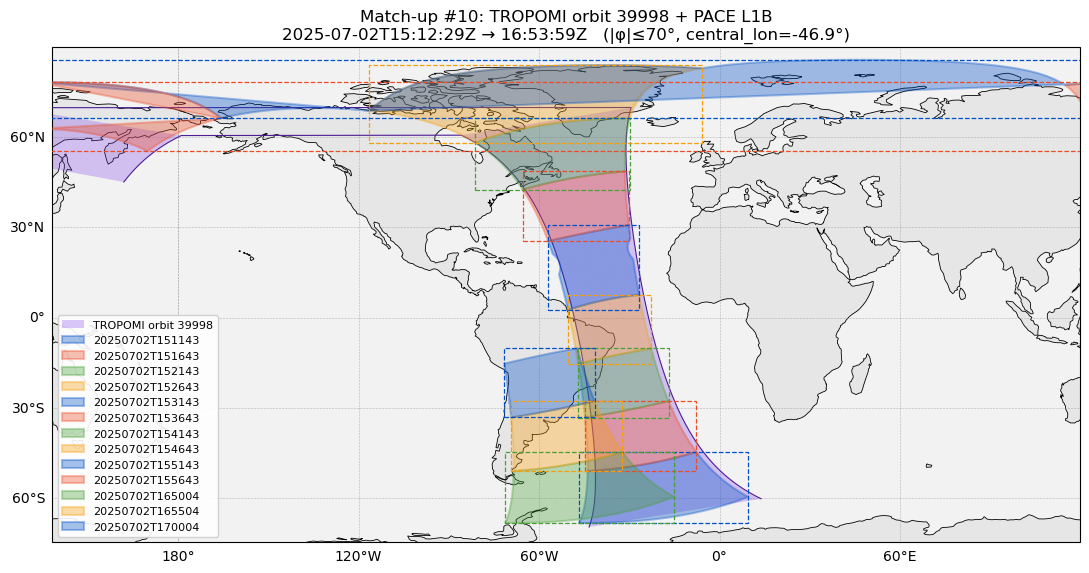

In [7]:
# Plot match-up #N: TROPOMI swath + PACE footprints (antimeridian-safe)
# Uses 1-based index from the printed "Co-located TROPOMI swaths" list.
#
# Swath fill: consecutive scanline quads so left[i]/right[i] stay paired.
# Clip scanlines with |lat| > LAT_CLIP_DEG (default 70°).

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon as MplPolygon

MATCH_ID = 10  # 1-based (as printed); swath_list is 0-based
LAT_CLIP_DEG = 70.0
SCAN_STRIDE = 10

if MATCH_ID < 1 or MATCH_ID > len(swath_list):
    raise IndexError(f"MATCH_ID={MATCH_ID} out of range 1..{len(swath_list)}")

sw = swath_list[MATCH_ID - 1]
tropo_path = Path(sw["tropomi_path"])
pace_names = sw["pace_granules"]
pace_paths = [PACE_DIR / name for name in pace_names]

print(f"Match-up #{MATCH_ID}")
print(f"  TROPOMI orbit={sw['orbit']}  {sw['tropomi']}")
print(f"  {sw['tropomi_start'][:19]}Z → {sw['tropomi_end'][11:19]}Z")
print(f"  PACE granules ({len(pace_paths)}):")
for name in pace_names:
    print(f"    {name}")


# ── helpers ───────────────────────────────────────────────────────────────────

def circular_mean_lon(lon: np.ndarray) -> float:
    lon = np.asarray(lon, dtype=float)
    lon = lon[np.isfinite(lon)]
    if lon.size == 0:
        return 0.0
    return float(np.rad2deg(np.angle(np.mean(np.exp(1j * np.deg2rad(lon))))))


def unwrap_lon(lon: np.ndarray, center: float) -> np.ndarray:
    lon = np.asarray(lon, dtype=float)
    return ((lon - center + 180.0) % 360.0) - 180.0 + center


def align_lon_to_ref(lon: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """Per-point ±360 so each lon lies within ±180° of ref (same shape)."""
    lon = np.asarray(lon, dtype=float)
    ref = np.asarray(ref, dtype=float)
    return lon - 360.0 * np.round((lon - ref) / 360.0)


def tropomi_swath_edges(path: Path, scan_stride: int = SCAN_STRIDE):
    """Return left/right edges; left[i] and right[i] are the same scanline."""
    with nc.Dataset(path) as ds:
        g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
        lat = np.asarray(g["latitude"][0, ::scan_stride, :], dtype=float)
        lon = np.asarray(g["longitude"][0, ::scan_stride, :], dtype=float)
    # ground_pixel 0 and -1 on the *same* scanline index
    return lon[:, 0], lat[:, 0], lon[:, -1], lat[:, -1]


def clip_edges_by_lat(left_lon, left_lat, right_lon, right_lat, lat_max: float):
    """Keep only scanlines where both edges have |lat| ≤ lat_max."""
    left_lon = np.asarray(left_lon, float)
    left_lat = np.asarray(left_lat, float)
    right_lon = np.asarray(right_lon, float)
    right_lat = np.asarray(right_lat, float)
    keep = (
        np.isfinite(left_lat) & np.isfinite(right_lat)
        & np.isfinite(left_lon) & np.isfinite(right_lon)
        & (np.abs(left_lat) <= lat_max)
        & (np.abs(right_lat) <= lat_max)
    )
    n_keep = int(keep.sum())
    print(f"  lat clip |φ|≤{lat_max:g}°: kept {n_keep} / {len(keep)} scanlines")
    if n_keep < 2:
        raise RuntimeError("Too few scanlines after latitude clip")
    return left_lon[keep], left_lat[keep], right_lon[keep], right_lat[keep]


def swath_quads(left_lon, left_lat, right_lon, right_lat, center: float):
    """
    Build one quad per consecutive scanline pair.
    Vertices (same scanline index on left/right):
      i  : left[i], right[i]
      i+1: left[i+1], right[i+1]
    Quad order: left[i] → left[i+1] → right[i+1] → right[i]
    """
    left_lon = np.asarray(left_lon, float)
    right_lon = align_lon_to_ref(np.asarray(right_lon, float), left_lon)
    left_lat = np.asarray(left_lat, float)
    right_lat = np.asarray(right_lat, float)

    # unwrap onto map center for display
    left_lon_c = unwrap_lon(left_lon, center)
    right_lon_c = unwrap_lon(right_lon, center)
    # keep right on same branch as left per scanline after centering
    right_lon_c = align_lon_to_ref(right_lon_c, left_lon_c)

    quads = []
    for i in range(len(left_lon_c) - 1):
        # skip if a scanline step jumps wildly in lon (dateline remnant)
        if abs(left_lon_c[i + 1] - left_lon_c[i]) > 90:
            continue
        if abs(right_lon_c[i + 1] - right_lon_c[i]) > 90:
            continue
        xs = [
            left_lon_c[i], left_lon_c[i + 1],
            right_lon_c[i + 1], right_lon_c[i],
        ]
        ys = [
            left_lat[i], left_lat[i + 1],
            right_lat[i + 1], right_lat[i],
        ]
        quads.append((xs, ys))
    return quads, left_lon_c, left_lat, right_lon_c, right_lat


def pace_corner_ring(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with nc.Dataset(path) as ds:
        lat = np.asarray(ds["geolocation_data"]["latitude"][:], dtype=float)
        lon = np.asarray(ds["geolocation_data"]["longitude"][:], dtype=float)
    top = (lon[0, :], lat[0, :])
    right = (lon[1:, -1], lat[1:, -1])
    bottom = (lon[-1, -2::-1], lat[-1, -2::-1])
    left = (lon[-2:0:-1, 0], lat[-2:0:-1, 0])
    ring_lon = np.concatenate([top[0], right[0], bottom[0], left[0], top[0][:1]])
    ring_lat = np.concatenate([top[1], right[1], bottom[1], left[1], top[1][:1]])
    return ring_lon, ring_lat


def split_ring_jumps(lon: np.ndarray, lat: np.ndarray, jump_deg: float = 180.0):
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    pieces = []
    cur_lon, cur_lat = [lon[0]], [lat[0]]
    for i in range(1, len(lon)):
        if (not np.isfinite(lon[i])) or (not np.isfinite(lat[i])) or (
            abs(lon[i] - lon[i - 1]) > jump_deg
        ):
            if len(cur_lon) >= 3:
                pieces.append((np.asarray(cur_lon), np.asarray(cur_lat)))
            cur_lon, cur_lat = [], []
            if np.isfinite(lon[i]) and np.isfinite(lat[i]):
                cur_lon.append(lon[i])
                cur_lat.append(lat[i])
        else:
            cur_lon.append(lon[i])
            cur_lat.append(lat[i])
    if len(cur_lon) >= 3:
        pieces.append((np.asarray(cur_lon), np.asarray(cur_lat)))
    return pieces


# ── load + clip TROPOMI edges (same scanline index on L/R) ────────────────────
left_lon, left_lat, right_lon, right_lat = tropomi_swath_edges(tropo_path)
left_lon, left_lat, right_lon, right_lat = clip_edges_by_lat(
    left_lon, left_lat, right_lon, right_lat, LAT_CLIP_DEG
)

pace_rings = [pace_corner_ring(pp) for pp in pace_paths]
ref_lon = np.concatenate([r[0] for r in pace_rings]) if pace_rings else left_lon
center = circular_mean_lon(ref_lon)
print(f"  map central_longitude = {center:.1f}°")

quads, left_lon_c, left_lat_c, right_lon_c, right_lat_c = swath_quads(
    left_lon, left_lat, right_lon, right_lat, center
)
print(f"  swath quads drawn: {len(quads)}")

pace_rings_c = [(unwrap_lon(rlon, center), rlat) for rlon, rlat in pace_rings]

all_lon = [left_lon_c, right_lon_c] + [r[0] for r in pace_rings_c]
all_lat = [left_lat_c, right_lat_c] + [r[1] for r in pace_rings_c]
lon0 = float(np.nanmin([np.nanmin(a) for a in all_lon]))
lon1 = float(np.nanmax([np.nanmax(a) for a in all_lon]))
lat0 = float(np.nanmin([np.nanmin(a) for a in all_lat]))
lat1 = float(np.nanmax([np.nanmax(a) for a in all_lat]))
pad = 5.0

proj = ccrs.PlateCarree(central_longitude=center)
pc = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={"projection": proj})
ax.set_extent(
    [lon0 - pad, lon1 + pad, max(-90, lat0 - pad), min(90, lat1 + pad)],
    crs=pc,
)
ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="0.95", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", linestyle=":")
gl.top_labels = False
gl.right_labels = False

# TROPOMI swath as same-scanline quads
for j, (xs, ys) in enumerate(quads):
    ax.fill(
        xs, ys,
        transform=pc,
        facecolor="#7C3AED", alpha=0.28, edgecolor="none",
        label=f"TROPOMI orbit {sw['orbit']}" if j == 0 else None,
        zorder=2,
    )
# outline left/right edges
ax.plot(left_lon_c, left_lat_c, transform=pc, color="#4C1D95", lw=0.8, zorder=3)
ax.plot(right_lon_c, right_lat_c, transform=pc, color="#4C1D95", lw=0.8, zorder=3)

colors = ["#0050C7", "#EC4B26", "#47A037", "#F59E0B"]
for i, ((rlon, rlat), name) in enumerate(zip(pace_rings, pace_names)):
    c = colors[i % len(colors)]
    rlon_c = unwrap_lon(rlon, center)
    for j, (plon, plat) in enumerate(split_ring_jumps(rlon_c, rlat)):
        ax.fill(
            plon, plat,
            transform=pc,
            facecolor=c, alpha=0.35, edgecolor=c, linewidth=1.5,
            label=(name.replace("PACE_OCI.", "").replace(".L1B.V3.nc", "") if j == 0 else None),
            zorder=4,
        )
    bb_lon0, bb_lon1 = float(np.nanmin(rlon_c)), float(np.nanmax(rlon_c))
    bb_lat0, bb_lat1 = float(np.nanmin(rlat)), float(np.nanmax(rlat))
    ax.add_patch(
        MplPolygon(
            [
                (bb_lon0, bb_lat0), (bb_lon1, bb_lat0),
                (bb_lon1, bb_lat1), (bb_lon0, bb_lat1),
            ],
            closed=True, fill=False, linestyle="--", linewidth=0.9, edgecolor=c,
            transform=pc, zorder=5,
        )
    )

ax.set_title(
    f"Match-up #{MATCH_ID}: TROPOMI orbit {sw['orbit']} + PACE L1B\n"
    f"{sw['tropomi_start'][:19]}Z → {sw['tropomi_end'][11:19]}Z"
    f"   (|φ|≤{LAT_CLIP_DEG:g}°, central_lon={center:.1f}°)",
    fontsize=12,
)
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()


Match-up #10
TROPOMI : S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
PACE granules: 13
Filters: dist ≤ 2.5 km  AND  |Δt| ≤ 30 min  AND  OCI Lt(λ≥600) < 30
Strides: PACE=150, TROPO scan/pix=2/2


/tmp/ipykernel_909099/2401147407.py:39: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropo_path) as ds:


TROPOMI samples: 467,264  (grid (2086, 224))


/tmp/ipykernel_909099/2401147407.py:113: RuntimeWarning: All-NaN slice encountered
  lt_max = np.nanmax(lt, axis=0)  # (nscan_sub, npix_sub)


  [00] PACE_OCI.20250702T151143.L1B.V3.nc: geo=108  dark=42  dist=4  keep=4
  [01] PACE_OCI.20250702T151643.L1B.V3.nc: geo=108  dark=23  dist=4  keep=4
  [02] PACE_OCI.20250702T152143.L1B.V3.nc: geo=108  dark=49  dist=8  keep=8
  [03] PACE_OCI.20250702T152643.L1B.V3.nc: geo=108  dark=39  dist=7  keep=7
  [04] PACE_OCI.20250702T153143.L1B.V3.nc: geo=108  dark=23  dist=4  keep=4
  [05] PACE_OCI.20250702T153643.L1B.V3.nc: geo=108  dark=46  dist=10  keep=10
  [06] PACE_OCI.20250702T154143.L1B.V3.nc: geo=108  dark=3  dist=1  keep=1
  [07] PACE_OCI.20250702T154643.L1B.V3.nc: geo=108  dark=6  dist=2  keep=2
  [08] PACE_OCI.20250702T155143.L1B.V3.nc: geo=108  dark=1  dist=0  keep=0
  [09] PACE_OCI.20250702T155643.L1B.V3.nc: geo=90  dark=37  dist=7  keep=7
  [10] PACE_OCI.20250702T165004.L1B.V3.nc: geo=108  dark=44  dist=0  keep=0


  [11] PACE_OCI.20250702T165504.L1B.V3.nc: geo=108  dark=39  dist=1  keep=0
  [12] PACE_OCI.20250702T170004.L1B.V3.nc: geo=108  dark=1  dist=0  keep=0

PACE geo samples: 1,386  dark (Lt_red<=30): 353  dist hits: 48  kept: 47
Stored pixel_matches n=47  keys=['match_id', 'tropomi_path', 'pace_paths', 'max_dist_km', 'max_dt_min', 'lt_max', 'lt_mask_wl_min', 'pace_stride', 'tropo_scan_stride', 'tropo_pix_stride', 'pace_name', 'pace_file_idx', 'pace_scan', 'pace_pix', 'trop_scan', 'trop_pix', 'pace_lat', 'pace_lon', 'trop_lat', 'trop_lon', 'dist_km', 'dt_min', 'pace_sza', 'pace_vza', 'trop_sza', 'trop_vza']
  dist median=1.93 km  |Δt| median=25.64 min
  PACE  SZA median=42.2°  VZA median=28.6°
  TROPO SZA median=43.6°  VZA median=17.3°


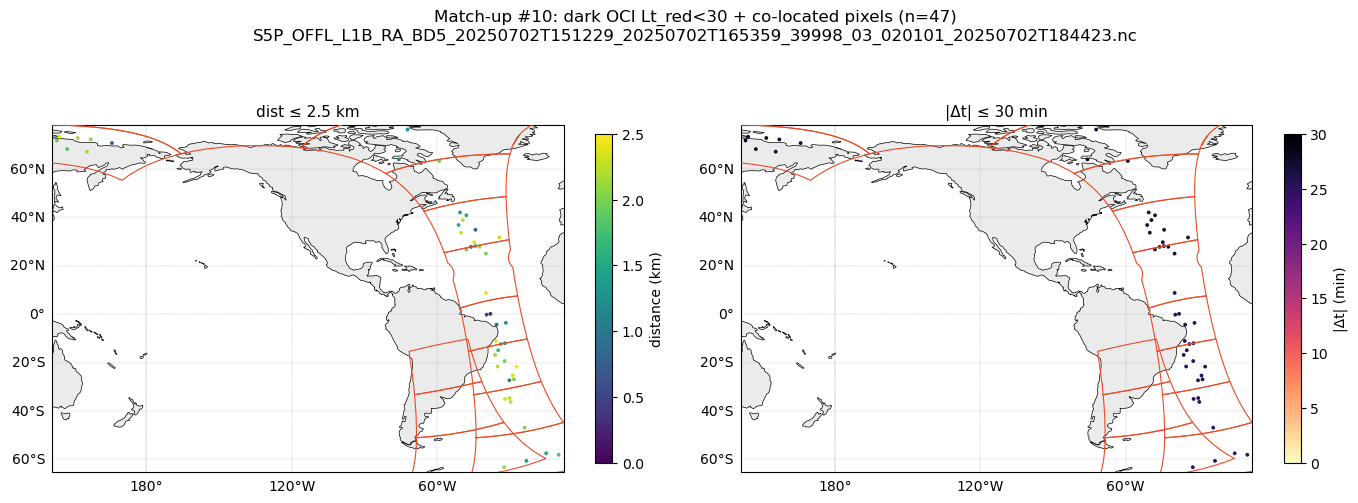

In [10]:
# Pixel-wise match-up for MATCH_ID (from plot cell): all PACE granules × TROPOMI
# Subsample + dist/Δt + OCI Lt_red pre-filter; store matches (incl. SZA/VZA).
#
# OCI dark-pixel mask BEFORE KD-tree (cheap block read of subsampled rhot):
#   keep only if max Lt(λ ≥ LT_MASK_WL_MIN) < LT_MAX
#   Lt = rhot * F0 * cos(SZA) / (π * esd)   [W m^-2 sr^-1 µm^-1]
#
# Timing: each scanline has one time; all pixels in that scan share it.
# Angles: PACE solar/sensor_zenith; TROPOMI solar/viewing_zenith_angle

from scipy.spatial import cKDTree
from netCDF4 import num2date

PACE_STRIDE_PIX = 150      # subsample PACE grid for speed
TROPO_SCAN_STRIDE = 2
TROPO_PIX_STRIDE = 2
MAX_DIST_KM = 2.5          # keep TROPOMI neighbors within this distance
MAX_DT_MIN = 30.0          # |Δt| threshold (minutes); adjustable
LT_MAX = 30.0              # OCI: keep if max Lt(λ ≥ LT_MASK_WL_MIN) < this
LT_MASK_WL_MIN = 600.0     # nm; red and beyond (OCI red CCD)
R_EARTH_KM = 6371.0

print(f"Match-up #{MATCH_ID}")
print(f"TROPOMI : {tropo_path.name}")
print(f"PACE granules: {len(pace_paths)}")
print(
    f"Filters: dist ≤ {MAX_DIST_KM:g} km  AND  |Δt| ≤ {MAX_DT_MIN:g} min  "
    f"AND  OCI Lt(λ≥{LT_MASK_WL_MIN:g}) < {LT_MAX:g}"
)
print(f"Strides: PACE={PACE_STRIDE_PIX}, TROPO scan/pix={TROPO_SCAN_STRIDE}/{TROPO_PIX_STRIDE}")

def lonlat_to_xyz(lon, lat):
    lon_r = np.deg2rad(lon)
    lat_r = np.deg2rad(lat)
    cl = np.cos(lat_r)
    return np.column_stack([cl * np.cos(lon_r), cl * np.sin(lon_r), np.sin(lat_r)])

# ── load TROPOMI once (subsampled) ────────────────────────────────────────────
with nc.Dataset(tropo_path) as ds:
    g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
    obs = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
    trop_lat = np.asarray(
        g["latitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_lon = np.asarray(
        g["longitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_sza = np.asarray(
        g["solar_zenith_angle"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_vza = np.asarray(
        g["viewing_zenith_angle"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    t0 = float(np.asarray(obs["time"][:]).ravel()[0])
    dt_ms = np.asarray(obs["delta_time"][0, :], dtype=float)
    trop_t_units = obs["time"].units

trop_shape = trop_lat.shape
trop_scan_time = np.array(
    num2date(t0 + dt_ms / 1000.0, units=trop_t_units, only_use_cftime_datetimes=False),
    dtype="datetime64[ms]",
)

trop_ok = np.isfinite(trop_lat) & np.isfinite(trop_lon)
trop_flat_i = np.flatnonzero(trop_ok)
trop_xyz = lonlat_to_xyz(trop_lon.ravel()[trop_flat_i], trop_lat.ravel()[trop_flat_i])
tree = cKDTree(trop_xyz)
print(f"TROPOMI samples: {trop_xyz.shape[0]:,}  (grid {trop_shape})")

# ── accumulate matchup pixels over all PACE granules ──────────────────────────
chunks: list[dict] = []
n_pace_geo = 0
n_pace_dark = 0
n_dist_total = 0
n_keep_total = 0

for i_pace, pace_path in enumerate(pace_paths):
    with nc.Dataset(pace_path) as ds:
        geo = ds["geolocation_data"]
        pace_lat = np.asarray(
            geo["latitude"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_lon = np.asarray(
            geo["longitude"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_sza = np.asarray(
            geo["solar_zenith"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_vza = np.asarray(
            geo["sensor_zenith"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_t_var = ds["scan_line_attributes"]["time"]
        pace_t_all = np.asarray(pace_t_var[:], dtype=float)
        pace_t_units = pace_t_var.units

        # OCI Lt_red pre-filter (subsampled hyperslab — much cheaper than per-match I/O)
        esd = float(getattr(ds, "earth_sun_distance_correction", 1.0))
        wl = np.asarray(ds["sensor_band_parameters"]["red_wavelength"][:], dtype=float)
        f0 = np.asarray(ds["sensor_band_parameters"]["red_solar_irradiance"][:], dtype=float)
        ib = np.flatnonzero(wl >= LT_MASK_WL_MIN)
        if ib.size == 0:
            raise RuntimeError(f"No OCI red bands ≥ {LT_MASK_WL_MIN:g} nm in {pace_path.name}")
        i0, i1 = int(ib[0]), int(ib[-1]) + 1
        rhot = np.asarray(
            ds["observation_data"]["rhot_red"][i0:i1, ::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX],
            dtype=float,
        )  # (nbands, nscan_sub, npix_sub)
        rhot = np.where(rhot > 0, rhot, np.nan)
        f0_b = f0[i0:i1][:, None, None]
        mu0 = np.cos(np.deg2rad(pace_sza))[None, :, :]
        mu0 = np.where(mu0 > 1e-6, mu0, np.nan)
        lt = rhot * f0_b * mu0 / (np.pi * esd)  # W m^-2 sr^-1 µm^-1
        lt_max = np.nanmax(lt, axis=0)  # (nscan_sub, npix_sub)
        dark = np.isfinite(lt_max) & (lt_max < LT_MAX)

    pace_shape = pace_lat.shape
    pace_scan_time = np.array(
        num2date(pace_t_all, units=pace_t_units, only_use_cftime_datetimes=False),
        dtype="datetime64[ms]",
    )

    pace_ok = np.isfinite(pace_lat) & np.isfinite(pace_lon)
    n_geo = int(pace_ok.sum())
    pace_ok &= dark
    n_dark = int(pace_ok.sum())
    n_pace_geo += n_geo
    n_pace_dark += n_dark

    pace_flat_i = np.flatnonzero(pace_ok)
    if pace_flat_i.size == 0:
        print(
            f"  [{i_pace:02d}] {pace_path.name}: "
            f"geo={n_geo:,}  dark={n_dark:,}  — skip (all bright/invalid)"
        )
        continue

    pace_xyz = lonlat_to_xyz(
        pace_lon.ravel()[pace_flat_i], pace_lat.ravel()[pace_flat_i]
    )

    chord, nn = tree.query(pace_xyz, k=1, workers=-1)
    dist_km = 2.0 * R_EARTH_KM * np.arcsin(np.clip(chord / 2.0, 0.0, 1.0))
    close_dist = dist_km <= MAX_DIST_KM

    pace_ji_all = np.unravel_index(pace_flat_i, pace_shape)
    trop_ji_nn = np.unravel_index(trop_flat_i[nn], trop_shape)
    pace_scan_orig = np.clip(
        pace_ji_all[0].astype(np.int64) * PACE_STRIDE_PIX, 0, len(pace_scan_time) - 1
    )
    trop_scan_orig = np.clip(
        trop_ji_nn[0].astype(np.int64) * TROPO_SCAN_STRIDE, 0, len(trop_scan_time) - 1
    )

    dt_min = (
        (trop_scan_time[trop_scan_orig] - pace_scan_time[pace_scan_orig])
        .astype("timedelta64[ms]")
        .astype(np.float64)
        / 60_000.0
    )
    keep = close_dist & (np.abs(dt_min) <= MAX_DT_MIN)

    n_dist = int(close_dist.sum())
    n_keep = int(keep.sum())
    n_dist_total += n_dist
    n_keep_total += n_keep
    print(
        f"  [{i_pace:02d}] {pace_path.name}: "
        f"geo={n_geo:,}  dark={n_dark:,}  dist={n_dist:,}  keep={n_keep:,}"
    )
    if n_keep == 0:
        continue

    pace_ji = np.unravel_index(pace_flat_i[keep], pace_shape)
    trop_ji = np.unravel_index(trop_flat_i[nn[keep]], trop_shape)
    pf = pace_flat_i[keep]
    tf = trop_flat_i[nn[keep]]

    chunks.append(
        {
            "pace_file_idx": np.full(n_keep, i_pace, dtype=np.int16),
            "pace_name": np.full(n_keep, pace_path.name),
            "pace_scan": (pace_ji[0].astype(np.int32) * PACE_STRIDE_PIX),
            "pace_pix": (pace_ji[1].astype(np.int32) * PACE_STRIDE_PIX),
            "trop_scan": (trop_ji[0].astype(np.int32) * TROPO_SCAN_STRIDE),
            "trop_pix": (trop_ji[1].astype(np.int32) * TROPO_PIX_STRIDE),
            "pace_lat": pace_lat.ravel()[pf].astype(np.float32),
            "pace_lon": pace_lon.ravel()[pf].astype(np.float32),
            "trop_lat": trop_lat.ravel()[tf].astype(np.float32),
            "trop_lon": trop_lon.ravel()[tf].astype(np.float32),
            "dist_km": dist_km[keep].astype(np.float32),
            "dt_min": dt_min[keep].astype(np.float32),
            "pace_sza": pace_sza.ravel()[pf].astype(np.float32),
            "pace_vza": pace_vza.ravel()[pf].astype(np.float32),
            "trop_sza": trop_sza.ravel()[tf].astype(np.float32),
            "trop_vza": trop_vza.ravel()[tf].astype(np.float32),
        }
    )

print(
    f"\nPACE geo samples: {n_pace_geo:,}  dark (Lt_red<={LT_MAX:g}): {n_pace_dark:,}  "
    f"dist hits: {n_dist_total:,}  kept: {n_keep_total:,}"
)

if not chunks:
    pixel_matches = None
    print("No matches after dark + dist + Δt filters.")
else:
    keys = [k for k in chunks[0] if k != "pace_name"]
    pixel_matches = {
        "match_id": MATCH_ID,
        "tropomi_path": str(tropo_path),
        "pace_paths": [str(p) for p in pace_paths],
        "max_dist_km": MAX_DIST_KM,
        "max_dt_min": MAX_DT_MIN,
        "lt_max": LT_MAX,
        "lt_mask_wl_min": LT_MASK_WL_MIN,
        "pace_stride": PACE_STRIDE_PIX,
        "tropo_scan_stride": TROPO_SCAN_STRIDE,
        "tropo_pix_stride": TROPO_PIX_STRIDE,
        "pace_name": np.concatenate([c["pace_name"] for c in chunks]),
    }
    for k in keys:
        pixel_matches[k] = np.concatenate([c[k] for c in chunks])

    print(f"Stored pixel_matches n={n_keep_total:,}  keys={list(pixel_matches.keys())}")
    print(
        f"  dist median={np.median(pixel_matches['dist_km']):.2f} km  "
        f"|Δt| median={np.median(np.abs(pixel_matches['dt_min'])):.2f} min"
    )
    print(
        f"  PACE  SZA median={np.nanmedian(pixel_matches['pace_sza']):.1f}°  "
        f"VZA median={np.nanmedian(pixel_matches['pace_vza']):.1f}°"
    )
    print(
        f"  TROPO SZA median={np.nanmedian(pixel_matches['trop_sza']):.1f}°  "
        f"VZA median={np.nanmedian(pixel_matches['trop_vza']):.1f}°"
    )

    # overview map (all granules), colored by distance
    fig, axes = plt.subplots(
        1, 2, figsize=(14, 5.5),
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=center)},
    )
    pc = ccrs.PlateCarree()
    lon_u = unwrap_lon(pixel_matches["pace_lon"], center)
    plat_u = pixel_matches["pace_lat"]
    extent = [
        float(np.nanmin(lon_u)) - 2, float(np.nanmax(lon_u)) + 2,
        float(np.nanmin(plat_u)) - 2, float(np.nanmax(plat_u)) + 2,
    ]

    ax = axes[0]
    ax.scatter(
        lon_u, plat_u, c=pixel_matches["dist_km"], s=3, cmap="viridis",
        transform=pc, vmin=0, vmax=MAX_DIST_KM, zorder=3,
    )
    for pp in pace_paths:
        rlon, rlat = pace_corner_ring(pp)
        for plon, plat in split_ring_jumps(unwrap_lon(rlon, center), rlat):
            ax.plot(plon, plat, transform=pc, color="#EC4B26", lw=0.8, zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(
        plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, MAX_DIST_KM)),
        ax=ax, shrink=0.7, label="distance (km)",
    )
    ax.set_extent(extent, crs=pc)
    ax.set_title(f"dist ≤ {MAX_DIST_KM:g} km", fontsize=11)

    ax = axes[1]
    abs_dt = np.abs(pixel_matches["dt_min"])
    ax.scatter(
        lon_u, plat_u, c=abs_dt, s=3, cmap="magma_r",
        transform=pc, vmin=0, vmax=MAX_DT_MIN, zorder=3,
    )
    for pp in pace_paths:
        rlon, rlat = pace_corner_ring(pp)
        for plon, plat in split_ring_jumps(unwrap_lon(rlon, center), rlat):
            ax.plot(plon, plat, transform=pc, color="#EC4B26", lw=0.8, zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(
        plt.cm.ScalarMappable(cmap="magma_r", norm=plt.Normalize(0, MAX_DT_MIN)),
        ax=ax, shrink=0.7, label="|Δt| (min)",
    )
    ax.set_extent(extent, crs=pc)
    ax.set_title(f"|Δt| ≤ {MAX_DT_MIN:g} min", fontsize=11)

    fig.suptitle(
        f"Match-up #{MATCH_ID}: dark OCI Lt_red<{LT_MAX:g} + co-located pixels "
        f"(n={n_keep_total:,})\n{tropo_path.name}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


# Summary: co-location criteria & TROPOMI→OCI simulation

### Match-up criteria

**Granule pairing (TROPOMI BD5 L1B ↔ PACE OCI L1B)**
- Time windows from filenames, with a maximum mid-point / window separation of `DT_MAX_MIN` (default **30 min**).
- Geographic overlap via bounding boxes (with TROPOMI along-track chunking for antimeridian safety).
- Current exploration window: early July 2025 (`DAY_END`), subsampled PACE listing via `PACE_STRIDE`.

**Pixel pairing (within a chosen `MATCH_ID` swath)**
| Criterion | Default | Notes |
|-----------|---------|--------|
| Spatial distance | ≤ **2.5 km** | Great-circle nearest TROPOMI neighbor (KD-tree on subsampled grids) |
| Time difference \|Δt\| | ≤ **30 min** | Scan-line times (TROPOMI `time+δt`; OCI `scan_line_attributes/time`) |
| OCI dark-pixel prefilter | max \(L_t(\lambda\ge 600\,\mathrm{nm}) < **30**\) | \(L_t=\rho_t F_0\cos(\mathrm{SZA})/(\pi\,\mathrm{esd})\); applied *before* NN |
| Grid subsampling | PACE stride **150**; TROPOMI scan/pix stride **2** | Speed knob — not a science requirement |

Stored per-pair geometry includes lat/lon, SZA/VZA (both sensors), `dist_km`, `dt_min`.

